In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import deque

# Fix randomness for reproducible results
np.random.seed(42)

In [ ]:
def make_frozen_lake(map_desc=None, is_slippery=False, render_mode=None):
    """
    Creates a FrozenLake-v1 environment.
    If map_desc is None, default 4x4 map is used.
    """
    if map_desc is None:
        env = gym.make("FrozenLake-v1", is_slippery=is_slippery, render_mode=render_mode)
    else:
        env = gym.make("FrozenLake-v1", desc=map_desc, is_slippery=is_slippery, render_mode=render_mode)
    return env


def epsilon_greedy_action(Q, state, env, epsilon):
    """Choose an action using epsilon-greedy policy with random tie-breaking."""
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        q_values = Q[state]
        max_q = np.max(q_values)
        max_actions = np.where(q_values == max_q)[0]
        return np.random.choice(max_actions)


def moving_average(values, window_size=100):
    """Simple moving average."""
    if len(values) < window_size:
        return np.array(values, dtype=float)
    return np.convolve(values, np.ones(window_size) / window_size, mode="valid")


def plot_moving_average(rewards, window_size=100, title="Moving Average Reward"):
    ma = moving_average(rewards, window_size)
    plt.figure(figsize=(10, 4))
    plt.plot(ma)
    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(f"Average Reward ({window_size}-episode window)")
    plt.grid(True)
    plt.show()


def evaluate_agent(Q, env_name="FrozenLake-v1", map_desc=None, is_slippery=False, episodes=3, sleep_time=0.5):
    """
    Evaluate a trained Q-table without exploration.
    Uses render_mode='human' for visual evaluation.
    """
    env = make_frozen_lake(map_desc=map_desc, is_slippery=is_slippery, render_mode="human")

    for ep in range(episodes):
        state, _ = env.reset(seed=42)
        done = False
        total_reward = 0

        while not done:
            q_values = Q[state]
            max_q = np.max(q_values)
            best_actions = np.where(q_values == max_q)[0]
            action = np.random.choice(best_actions)

            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
            time.sleep(sleep_time)

        print(f"Episode {ep + 1}: total reward = {total_reward}")

    env.close()

In [ ]:
env = make_frozen_lake(is_slippery=False)

np.random.seed(42)
env.reset(seed=42)
env.action_space.seed(42)

state, _ = env.reset(seed=42)

n_states = env.observation_space.n
n_actions = env.action_space.n
Q_task1 = np.zeros((n_states, n_actions))

print("State space:", n_states)
print("Action space:", n_actions)
print("Q-table shape:", Q_task1.shape)

State space: 16
Action space: 4
Q-table shape: (16, 4)


In [ ]:
alpha = 0.8
gamma = 0.95
epsilon = 1.0
min_epsilon = 0.01
decay = 0.005
episodes = 2000

episode_rewards_task1 = []

for episode in range(episodes):
    state, _ = env.reset(seed=42)
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy_action(Q_task1, state, env, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Bellman update (Q-learning)
        td_target = reward + gamma * np.max(Q_task1[next_state])
        Q_task1[state, action] = Q_task1[state, action] + alpha * (td_target - Q_task1[state, action])

        state = next_state
        total_reward += reward

    episode_rewards_task1.append(total_reward)

    # Exponential epsilon decay
    epsilon = max(min_epsilon, epsilon * np.exp(-decay))

In [ ]:
print("Final Q-table (Task 1):")
print(Q_task1)

print("\nEvaluation on 3 episodes with epsilon = 0:")
evaluate_agent(Q_task1, is_slippery=False, episodes=3, sleep_time=0.5)

Final Q-table (Task 1):
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.66330829 0.69832589]
 [0.69833509 0.68589119 0.61406489 0.        ]
 [0.66197372 0.         0.         0.45669898]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.63562594]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.86287141 0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]

Evaluation on 3 episodes with epsilon = 0:
Episode 1: total reward = 1
Episode 2: total reward = 1
Episode 3: total reward = 1


In [ ]:
custom_map_6x6 = [
    "SFFFFF",
    "HHHHHF",
    "FFFFFF",
    "FHHHHH",
    "FFFFFF",
    "HHHHHG"
]

env2 = make_frozen_lake(map_desc=custom_map_6x6, is_slippery=False)

np.random.seed(42)
env2.reset(seed=42)
env2.action_space.seed(42)

n_states2 = env2.observation_space.n
n_actions2 = env2.action_space.n
Q_task2 = np.zeros((n_states2, n_actions2))

print("State space:", n_states2)
print("Action space:", n_actions2)
print("Q-table shape:", Q_task2.shape)

State space: 36
Action space: 4
Q-table shape: (36, 4)


In [ ]:
alpha = 0.8
gamma = 0.95
epsilon = 1.0
min_epsilon = 0.01
decay = 0.001
episodes = 5000

episode_rewards_task2 = []

for episode in range(episodes):
    state, _ = env2.reset(seed=42)
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy_action(Q_task2, state, env2, epsilon)

        next_state, reward, terminated, truncated, info = env2.step(action)
        done = terminated or truncated

        td_target = reward + gamma * np.max(Q_task2[next_state])
        Q_task2[state, action] = Q_task2[state, action] + alpha * (td_target - Q_task2[state, action])

        state = next_state
        total_reward += reward

    episode_rewards_task2.append(total_reward)
    epsilon = max(min_epsilon, epsilon * np.exp(-decay))

In [ ]:
print("Final Q-table shape (Task 2):", Q_task2.shape)

Final Q-table shape (Task 2): (36, 4)


In [ ]:
env3 = make_frozen_lake(map_desc=custom_map_6x6, is_slippery=False)

np.random.seed(42)
env3.reset(seed=42)
env3.action_space.seed(42)

Q_task3 = np.zeros((env3.observation_space.n, env3.action_space.n))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
min_epsilon = 0.01
decay = 0.001
episodes = 5000

episode_shaped_rewards_task3 = []

for episode in range(episodes):
    state, _ = env3.reset(seed=42)
    done = False
    total_shaped_reward = 0

    while not done:
        action = epsilon_greedy_action(Q_task3, state, env3, epsilon)

        next_state, reward, terminated, truncated, info = env3.step(action)
        done = terminated or truncated

        # Reward shaping
        if terminated and reward == 1.0:
            shaped_reward = 1.0          # goal reward
        elif terminated and reward == 0.0:
            shaped_reward = -1.0         # hole penalty
        else:
            shaped_reward = -0.01        # step cost on frozen tile

        td_target = shaped_reward + gamma * np.max(Q_task3[next_state])
        Q_task3[state, action] = Q_task3[state, action] + alpha * (td_target - Q_task3[state, action])

        state = next_state
        total_shaped_reward += shaped_reward

    episode_shaped_rewards_task3.append(total_shaped_reward)
    epsilon = max(min_epsilon, epsilon * np.exp(-decay))

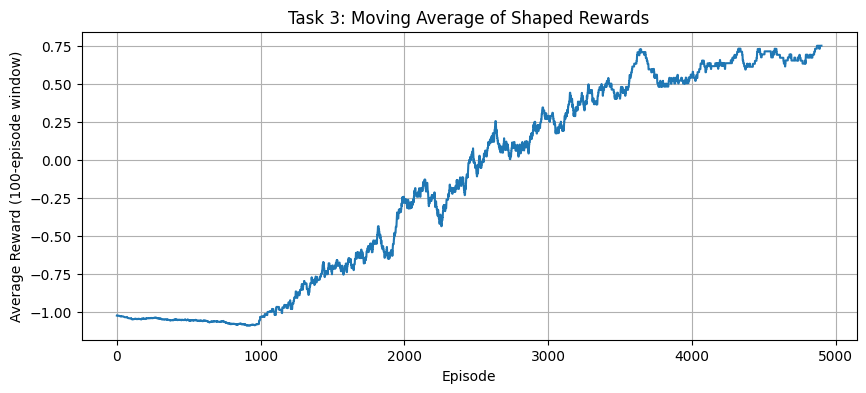

In [ ]:
plot_moving_average(
    episode_shaped_rewards_task3,
    window_size=100,
    title="Task 3: Moving Average of Shaped Rewards"
)

In [ ]:
env4 = make_frozen_lake(map_desc=custom_map_6x6, is_slippery=True)

np.random.seed(42)
env4.reset(seed=42)
env4.action_space.seed(42)

Q_task4 = np.zeros((env4.observation_space.n, env4.action_space.n))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
min_epsilon = 0.01
decay = 0.0005
episodes = 10000

episode_shaped_rewards_task4 = []

for episode in range(episodes):
    state, _ = env4.reset(seed=42)
    done = False
    total_shaped_reward = 0

    while not done:
        action = epsilon_greedy_action(Q_task4, state, env4, epsilon)

        next_state, reward, terminated, truncated, info = env4.step(action)
        done = terminated or truncated

        if terminated and reward == 1.0:
            shaped_reward = 1.0
        elif terminated and reward == 0.0:
            shaped_reward = -1.0
        else:
            shaped_reward = -0.01

        td_target = shaped_reward + gamma * np.max(Q_task4[next_state])
        Q_task4[state, action] = Q_task4[state, action] + alpha * (td_target - Q_task4[state, action])

        state = next_state
        total_shaped_reward += shaped_reward

    episode_shaped_rewards_task4.append(total_shaped_reward)
    epsilon = max(min_epsilon, epsilon * np.exp(-decay))

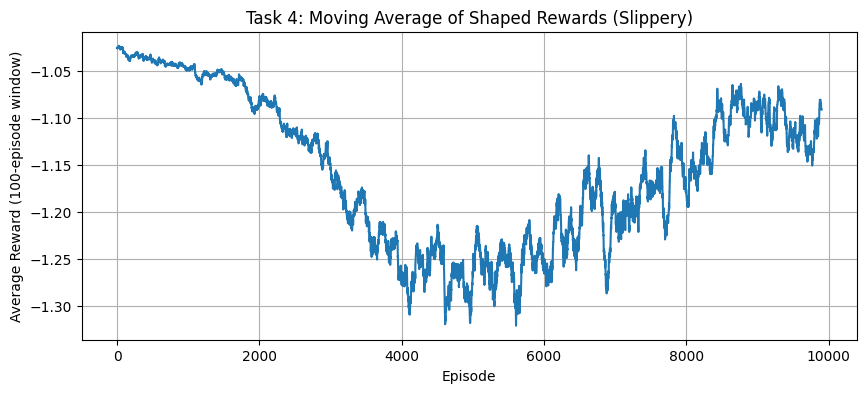

In [ ]:
plot_moving_average(
    episode_shaped_rewards_task4,
    window_size=100,
    title="Task 4: Moving Average of Shaped Rewards (Slippery)"
)

In [ ]:
print("Task 1 agent:")
evaluate_agent(Q_task1, is_slippery=False, episodes=3, sleep_time=0.5)

print("Task 2 agent:")
evaluate_agent(Q_task2, map_desc=custom_map_6x6, is_slippery=False, episodes=3, sleep_time=0.5)

print("Task 3 agent:")
evaluate_agent(Q_task3, map_desc=custom_map_6x6, is_slippery=False, episodes=3, sleep_time=0.5)

print("Task 4 agent:")
evaluate_agent(Q_task4, map_desc=custom_map_6x6, is_slippery=True, episodes=3, sleep_time=0.5)

Task 1 agent:
Episode 1: total reward = 1
Episode 2: total reward = 1
Episode 3: total reward = 1
Task 2 agent:
Episode 1: total reward = 0
Episode 2: total reward = 0
Episode 3: total reward = 0
Task 3 agent:
Episode 1: total reward = 1
Episode 2: total reward = 1
Episode 3: total reward = 1
Task 4 agent:
Episode 1: total reward = 0
Episode 2: total reward = 0
Episode 3: total reward = 0


Task 1 Question 5-

 Yes, the agent reaches the goal consistently in all 3 evaluation episodes when epsilon = 0.

 Task 2 Question 4-

 The agent learns a more conservative and safer policy, preferring paths that stay farther away from holes, even if they are longer.